In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from denit import utils

In [2]:
nspec = 8
#
# Leer información de "u_init.dat"
with open("remix/u_init.dat", "r") as f:
    spec_info = f.readlines()
key_string = "Aqueous variable activity species:"
isp = utils.find_index(spec_info, key_string, 1)
spec_names = [l.split(": ")[1].strip() for l in spec_info[isp:isp+nspec]]
print(spec_names)
#
# Leer información de la simulación 
with open("final_species.dat", "r") as f:
    lines = f.readlines()
steps = len(lines) // nspec
print(steps)
#
# Leer información del excel
denit_excel = pd.read_excel("remix/denit_2reacts_corregido.xlsx", 
                            sheet_name = "results", usecols=range(0,11), 
                            skiprows=4, header=None)
spe_names = [c.strip() for c in denit_excel.iloc[2:10,0]]
idx = 2
skip = 15
times = ["0.00d", "0.01d", "0.02d", "0.10d", "1.00d", "5.00d"]
ranges = [(idx + i*skip, idx + i*skip + nspec) for i in range(0, 6)]
print(ranges)

s_excel = []
for it in range(0,6):
    iini = ranges[it][0]
    ifin = ranges[it][1]
    s_excel.append(denit_excel.iloc[iini:ifin, 1:].to_numpy(dtype=float))


['h+', 'cl-', 'no3-', 'n2(aq)(p)', 'ch2o(aq)', 'hco3-', 'o2(aq)', 'co3-2']
500
[(2, 10), (17, 25), (32, 40), (47, 55), (62, 70), (77, 85)]


Specie:  7


co3-2


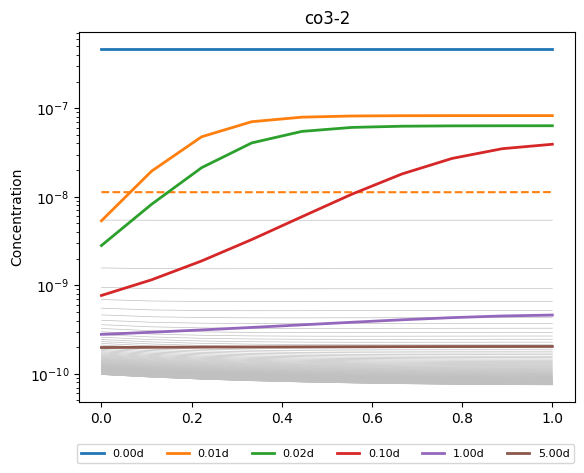

In [15]:
fig, ax = plt.subplots()
x = np.linspace(0, 1.0, 10)

s = int(input("Specie: "))
print(f"{spec_names[s]}")

ax.plot(x, [float(l) for l in lines[s].split()][1:], lw=1.5, ls = "--", color='C1')
for nt in range(1, steps, 5):
    ax.plot(x, [float(l) for l in lines[s + nt * nspec].split()][1:], lw=.5, color='silver')

for i, t in enumerate(times):
    ax.plot(x, s_excel[i][s], lw = 2.0, label=f"{times[i]}", zorder = 5)

plt.yscale("log")
#plt.xlabel("Distance")
plt.ylabel("Concentration")
plt.title(f"{spe_names[s]}")
plt.legend(loc='best', bbox_to_anchor=(0.51, -0.60, 0.5, 0.5), 
           ncol=8, fontsize=8)

plt.show()